In [1]:
# --- Imports ---
from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.stats import ttest_ind, mannwhitneyu, gaussian_kde
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
from tidepool_data_science_simulator.utils import DATA_DIR
from tidepool_data_science_simulator.evaluation.inspect_results import load_result
from tidepool_data_science_metrics.glucose.glucose import (
    percent_values_ge_70_le_180, percent_values_gt_180,
    percent_values_lt_70, blood_glucose_risk_index,
)

# --- Configuration ---
PROJECT_ROOT = Path(DATA_DIR) / "processed"
RESULT_DIR = PROJECT_ROOT / "autobolus_tempbasal_comparison_unannounced_meals_basal_cap_short_run2025_05_29_T_11_27_39"
HISTOGRAM_PATH = Path("/Users/mconn/Downloads/BG_Distribution_Histogram.csv")
METRIC_NAMES = [
    'Percent Time in Range (70 - 180 mg/dL)', 
    'Percent below Range (< 70 mg/dL)', 
    'Percent Time above Range (> 180 mg/dL)', 
    'Cumulative Insulin (U)', 
    'BGRI'
]
PAF_VALUES = ["paf=0.0", "paf=0.4"]

# --- Core Functions ---
def weighted_percentile(values, weights, percentiles):
    sorted_idx = np.argsort(values)
    cum_weights = np.cumsum(weights[sorted_idx])
    total = cum_weights[-1]
    pct = 100 * cum_weights / total
    return np.interp(percentiles, pct, values[sorted_idx])

def weighted_iqr(values, weights):
    return weighted_percentile(values, weights, [75])[0] - weighted_percentile(values, weights, [25])[0]

def weighted_mean_std(values, weights):
    mean = np.average(values, weights=weights)
    var = np.average((values - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)
 
def compare_kde_boxplot(
    data_1,
    data_2,
    weights=None,
    title="Comparison",
    ylabel="Value",
    label_1="Dataset 1",
    label_2="Dataset 2",
    color_1="#627cff",
    color_2="#271b45",
    bw_method=0.2,
    violin_width=0.4,
    box_width=0.05
):
    """
    Compare two datasets using KDEs and boxplots on a shared vertical axis.

    Parameters:
        data1: First dataset (1D array).
        data2: Second dataset (1D array).
        weights: Optional weights for computing KDE.
        title: Plot title.
        ylabel: Y-axis label.
        label1, label2: Labels for datasets.
        color1, color2: Colors for KDE and boxplot lines.
        bw_method: Bandwidth for KDE.
        violin_width: Max width of violin KDEs.
        box_width: Width of boxplots.
    """
    x_min = min(data_1.min(), data_2.min())
    x_max = max(data_1.max() , data_2.max())
    x_grid = np.linspace(x_min, x_max, 500)

    # KDEs
    kde_1 = gaussian_kde(data_1, weights=weights, bw_method=bw_method) 
    kde_2 = gaussian_kde(data_2, weights=weights, bw_method=bw_method)

    density_1 = kde_1(x_grid)
    density_2 = kde_2(x_grid)

    peaks_1, _ = find_peaks(density_1)
    modes_1 = x_grid[peaks_1]

    peaks_2, _ = find_peaks(density_2)
    modes_2 = x_grid[peaks_2]

    # Normalize KDEs
    density_1 /= density_1.max()
    density_2 /= density_2.max()

    # Add modes to labels
    print(f"{label_1} (mode(s): {', '.join([f'{m:.1f}' for m in modes_1])})" if len(modes_1) > 0 else label_1)
    print(f"{label_2} (mode(s): {', '.join([f'{m:.1f}' for m in modes_2])})" if len(modes_2) > 0 else label_2)
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.fill_betweenx(x_grid, (-density_1 * violin_width) - 0.1, -0.1, facecolor=color_1, alpha=1, label=label_1)
    ax.fill_betweenx(x_grid, 0.1, (density_2 * violin_width) + 0.1, facecolor=color_2, alpha=1, label=label_2)

    # Boxplots
    data_1_weighted = np.repeat(data_1, (weights * 10000).astype(int))
    data_2_weighted = np.repeat(data_2, (weights * 10000).astype(int))

    box_data = [data_1_weighted, data_2_weighted]
    positions = [-0.05, 0.05]
    box = ax.boxplot(box_data, vert=True, positions=positions, widths=box_width, patch_artist=True)

    line_width = 2.5
    for i, color in enumerate([color_1, color_2]):
        box['boxes'][i].set_facecolor('none')
        box['boxes'][i].set_edgecolor(color)
        box['boxes'][i].set_linewidth(line_width)

        box['medians'][i].set_color(color)
        box['medians'][i].set_linewidth(line_width)

        for j in [2*i, 2*i+1]:  # whiskers and caps
            box['whiskers'][j].set_color(color)
            box['whiskers'][j].set_linewidth(line_width)
            box['caps'][j].set_color(color)
            box['caps'][j].set_linewidth(line_width)

        if 'fliers' in box and i < len(box['fliers']):
            box['fliers'][i].set_markeredgecolor(color)
            box['fliers'][i].set_linewidth(line_width)

    ax.set_xlabel('Density')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    plt.tight_layout()
    plt.show()

def calculate_cumulative_insulin(df):
    return df['delivered_basal_insulin'].sum() + df['true_bolus'].sum()

def calculate_metrics(df):
    return (
        percent_values_ge_70_le_180(df['bg']),
        percent_values_lt_70(df['bg']),
        percent_values_gt_180(df['bg']),
        calculate_cumulative_insulin(df),
        blood_glucose_risk_index(df['bg'])[2],
    )

def group_files_by_user_ibg(files):
    grouped = defaultdict(lambda: {paf: [] for paf in PAF_VALUES})
    for file in files:
        parts = {kv.split("=")[0]: kv.split("=")[1] for kv in Path(file).stem.split("_") if "=" in kv}
        key = f"vp={parts['vp']}_patient_id={parts['id']}_ibg={parts['ibg']}"

        file_str = str(file) 
        for paf in PAF_VALUES:
            if paf in file_str:
                grouped[key][paf].append(file)
    return grouped

def load_histogram_weights(path):
    df = pd.read_csv(path)
    return {row['ibg']: row['proportion'] for _, row in df.iterrows()}

def process_pair_metrics(grouped_files, weights_dict, start_idx=137, hours=2):
    n = len(grouped_files)
    metrics_all = np.zeros((n, 5, 2))
    ibg_values = np.zeros(n)
    weights = np.zeros(n)
    insulin_diffs = []

    for idx, (key, files) in enumerate(grouped_files.items()):
        if not all(files[paf] for paf in PAF_VALUES):
            continue
        
        ibg = float(key.split("_ibg=")[1])
        if ibg < 70 or ibg > 180:
            continue

        df0 = pd.concat([load_result(f)[1] for f in files["paf=0.0"]])
        df1 = pd.concat([load_result(f)[1] for f in files["paf=0.4"]])

        slice_ = slice(start_idx, start_idx + hours * 12)
        m0 = calculate_metrics(df0.iloc[slice_])
        m1 = calculate_metrics(df1.iloc[slice_])

        for j in range(5):
            metrics_all[idx, j] = [m0[j], m1[j]]
        
        
        ibg_values[idx] = ibg
        weights[idx] = weights_dict.get(ibg, 0)
        insulin_diffs.append(m0[3] - m1[3])
    
    return metrics_all, ibg_values, weights, insulin_diffs

def summarize_and_plot(metrics_all, weights):
    summary = {}
    for i, name in enumerate(METRIC_NAMES):
        data_1 = metrics_all[:, i, 0]
        data_2 = metrics_all[:, i, 1]

        try:
            compare_kde_boxplot(data_1, data_2, weights, title=name,
                                ylabel=name, label_1="Temp Basal", label_2="Autobolus (0.4)")
        except Exception as e:
            print(f"Error plotting {name}: {e}")
            continue

        t_stat, p_val = ttest_ind(data_1, data_2, equal_var=False)
        u_stat, mw_p_val = mannwhitneyu(data_1, data_2, alternative='two-sided')
        med1, med2 = weighted_percentile(data_1, weights, 50), weighted_percentile(data_2, weights, 50)
        iqr1, iqr2 = weighted_iqr(data_1, weights), weighted_iqr(data_2, weights)
        mean1, std1 = weighted_mean_std(data_1, weights)
        mean2, std2 = weighted_mean_std(data_2, weights)

        summary[name] = {
            "Temp Basal": {"mean": mean1, "std": std1, "median": med1, "iqr": iqr1},
            "Autobolus (0.4)": {"mean": mean2, "std": std2, "median": med2, "iqr": iqr2},
            "t_stat": t_stat, "p_value": p_val,
            "mannwhitney_u_stat": u_stat, "mannwhitney_p_value": mw_p_val
        }
    return summary

def print_summary(summary):
    for metric, stats in summary.items():
        print(f"\nMetric: {metric}")
        for group, vals in stats.items():
            if isinstance(vals, dict):
                print(f"  {group}: Mean={vals['mean']:.2f}, Std={vals['std']:.2f}, Median={vals['median']:.2f}, IQR={vals['iqr']:.2f}")
            else:
                print(f"  {group}: {vals:.2f}")


    

Temp Basal (mode(s): 22.7)
Autobolus (0.4) (mode(s): 23.2, 99.8)


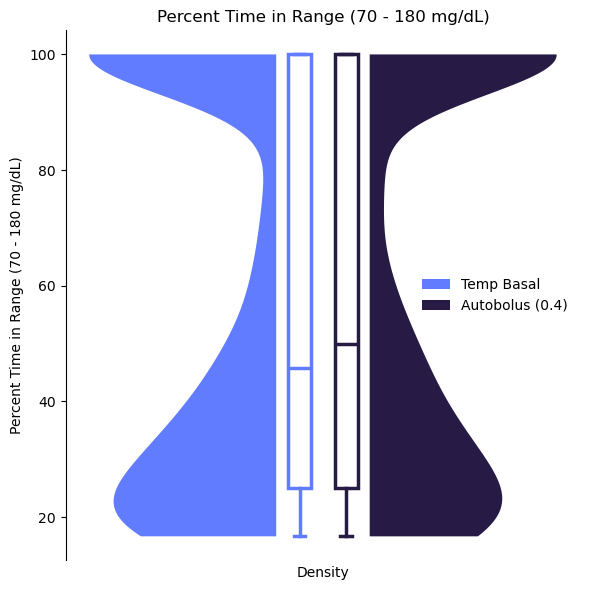

Error plotting Percent below Range (< 70 mg/dL): The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.
Temp Basal (mode(s): 76.8)
Autobolus (0.4) (mode(s): 0.2, 76.3)


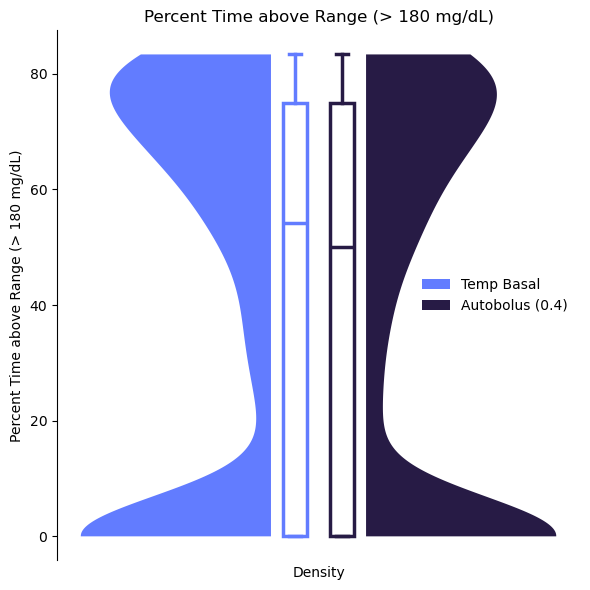

Temp Basal (mode(s): 3.5, 12.9, 15.0)
Autobolus (0.4) (mode(s): 3.5, 14.4, 15.9, 18.0, 19.9, 21.6)


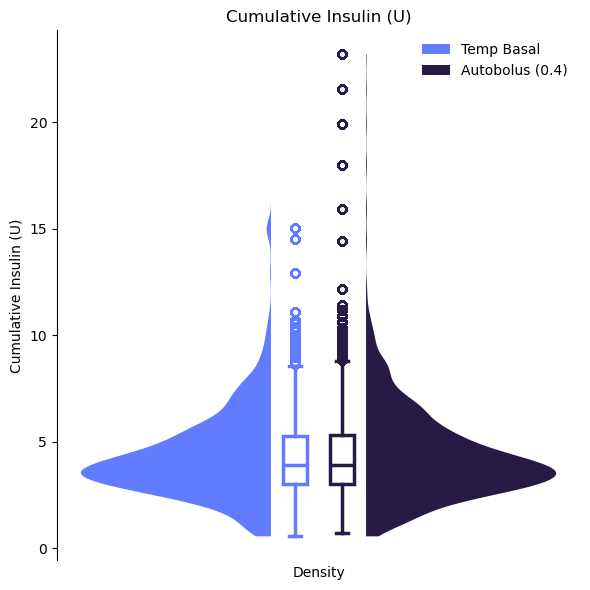

Temp Basal (mode(s): 5.7, 35.6, 102.2, 142.5)
Autobolus (0.4) (mode(s): 5.4, 32.3, 97.1, 139.0)


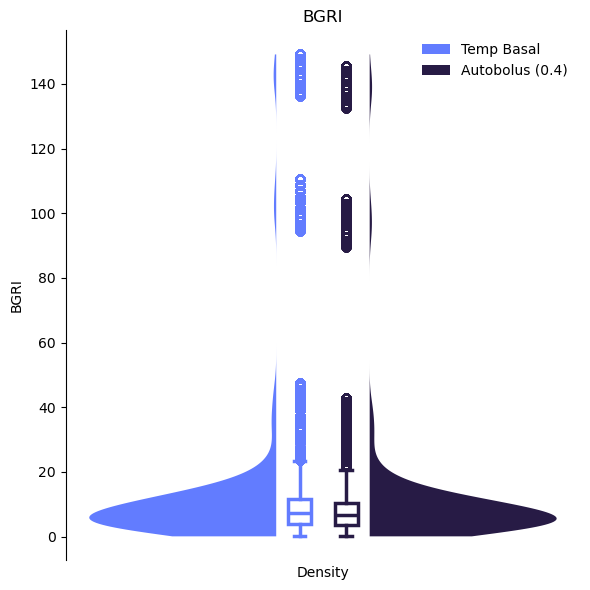


Metric: Percent Time in Range (70 - 180 mg/dL)
  Temp Basal: Mean=57.09, Std=34.93, Median=41.95, IQR=75.00
  Autobolus (0.4): Mean=60.43, Std=34.95, Median=50.00, IQR=75.00
  t_stat: -1.73
  p_value: 0.08
  mannwhitney_u_stat: 559370.50
  mannwhitney_p_value: 0.08

Metric: Percent Time above Range (> 180 mg/dL)
  Temp Basal: Mean=42.30, Std=34.64, Median=54.17, IQR=75.00
  Autobolus (0.4): Mean=39.01, Std=34.65, Median=50.00, IQR=72.87
  t_stat: 1.71
  p_value: 0.09
  mannwhitney_u_stat: 606581.50
  mannwhitney_p_value: 0.09

Metric: Cumulative Insulin (U)
  Temp Basal: Mean=4.31, Std=2.03, Median=3.92, IQR=2.23
  Autobolus (0.4): Mean=4.39, Std=2.27, Median=3.92, IQR=2.33
  t_stat: -0.71
  p_value: 0.48
  mannwhitney_u_stat: 586353.00
  mannwhitney_p_value: 0.83

Metric: BGRI
  Temp Basal: Mean=11.06, Std=18.48, Median=7.21, IQR=7.99
  Autobolus (0.4): Mean=10.32, Std=17.76, Median=6.66, IQR=6.95
  t_stat: 0.83
  p_value: 0.40
  mannwhitney_u_stat: 603959.00
  mannwhitney_p_value: 0

In [4]:
# --- Run Pipeline ---
if __name__ == "__main__":
    all_files = list(RESULT_DIR.glob("*.tsv"))
    grouped = group_files_by_user_ibg(all_files)
    weights_dict = load_histogram_weights(HISTOGRAM_PATH)

    metrics_all, ibg_values, weights, insulin_diffs = process_pair_metrics(grouped, weights_dict)

    summary = summarize_and_plot(metrics_all, weights)
    print_summary(summary)

In [ ]:
import matplotlib.pyplot as plt

def plot_ibg_histogram(histogram_df, font_size=18):
    # Set up plot aesthetics
    fig, ax = plt.subplots(figsize=(12, 4))
    bar_color = "#627cff"
    edge_color = "#271b45"

    # Extract data
    x = histogram_df['ibg'].values
    heights = histogram_df['proportion'].values

    # Plot the bar chart
    ax.bar(x, heights, width=10.0, color=bar_color, edgecolor=edge_color, linewidth=2.5)

    # Labeling and formatting
    ax.set_xlabel("Initial Blood Glucose (mg/dL)", fontsize=font_size)
    ax.set_ylabel("Proportion", fontsize=font_size)
    ax.set_title("Distribution of Initial Blood Glucose Value\nFrom TBDDP", fontsize=font_size + 2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=font_size)

    # Final layout and display
    plt.tight_layout()
    plt.show()

plot_ibg_histogram(histogram_df, font_size=18)

In [2]:
all_files = list(RESULT_DIR.glob("*.tsv"))
grouped = group_files_by_user_ibg(all_files)
weights_dict = load_histogram_weights(HISTOGRAM_PATH)

# Initialize storage
tir_results = {
    "hour": [],
    "mean_temp_basal": [],
    "std_temp_basal": [],
    "mean_autobolus": [],
    "std_autobolus": [],
    "median_temp_basal": [],
    "q1_temp_basal": [],
    "q3_temp_basal": [],
    "median_autobolus": [],
    "q1_autobolus": [],
    "q3_autobolus": []
}

for i in range(1, 9):
    metrics_all, ibg_values, weights, insulin_diffs = process_pair_metrics(grouped, weights_dict, hours=i)

    # Extract metric 0 (Time in Range)
    tir_temp_basal = metrics_all[:, 0, 0]
    tir_autobolus = metrics_all[:, 0, 1]

    # Mean & Std
    mean_tb, std_tb = weighted_mean_std(tir_temp_basal, weights)
    mean_ab, std_ab = weighted_mean_std(tir_autobolus, weights)

    # Median, Q1, Q3
    median_tb = weighted_percentile(tir_temp_basal, weights, 50)
    q1_tb = weighted_percentile(tir_temp_basal, weights, 25)
    q3_tb = weighted_percentile(tir_temp_basal, weights, 75)

    median_ab = weighted_percentile(tir_autobolus, weights, 50)
    q1_ab = weighted_percentile(tir_autobolus, weights, 25)
    q3_ab = weighted_percentile(tir_autobolus, weights, 75)

    # Store
    tir_results["hour"].append(i)
    tir_results["mean_temp_basal"].append(mean_tb)
    tir_results["std_temp_basal"].append(std_tb)
    tir_results["mean_autobolus"].append(mean_ab)
    tir_results["std_autobolus"].append(std_ab)
    tir_results["median_temp_basal"].append(median_tb)
    tir_results["q1_temp_basal"].append(q1_tb)
    tir_results["q3_temp_basal"].append(q3_tb)
    tir_results["median_autobolus"].append(median_ab)
    tir_results["q1_autobolus"].append(q1_ab)
    tir_results["q3_autobolus"].append(q3_ab)

tir_df = pd.DataFrame(tir_results)


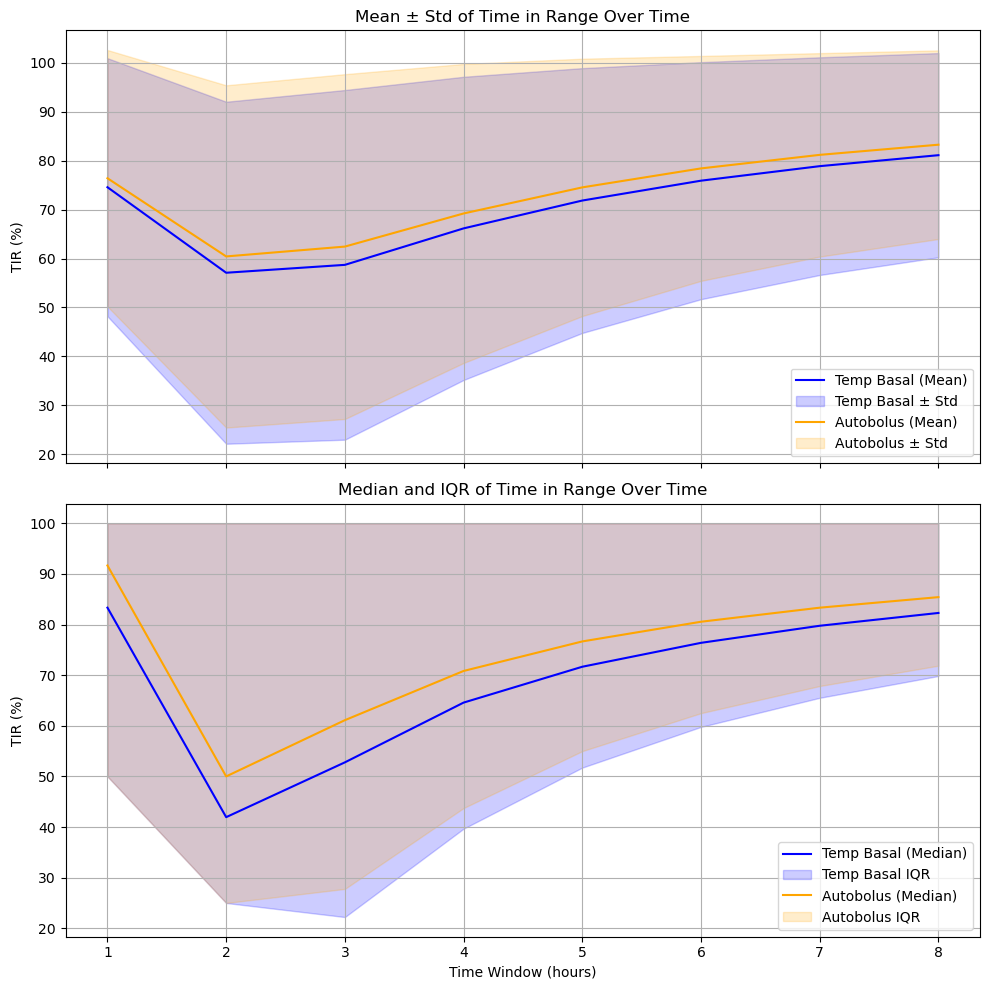

In [3]:
# Assume tir_df was created from the previous step
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# === 1. Mean ± Std ===
axes[0].plot(tir_df["hour"], tir_df["mean_temp_basal"], label="Temp Basal (Mean)", color="blue")
axes[0].fill_between(tir_df["hour"],
                     tir_df["mean_temp_basal"] - tir_df["std_temp_basal"],
                     tir_df["mean_temp_basal"] + tir_df["std_temp_basal"],
                     color="blue", alpha=0.2, label="Temp Basal ± Std")

axes[0].plot(tir_df["hour"], tir_df["mean_autobolus"], label="Autobolus (Mean)", color="orange")
axes[0].fill_between(tir_df["hour"],
                     tir_df["mean_autobolus"] - tir_df["std_autobolus"],
                     tir_df["mean_autobolus"] + tir_df["std_autobolus"],
                     color="orange", alpha=0.2, label="Autobolus ± Std")

axes[0].set_title("Mean ± Std of Time in Range Over Time")
axes[0].set_ylabel("TIR (%)")
axes[0].legend()
axes[0].grid(True)

# === 2. Median with IQR ===
axes[1].plot(tir_df["hour"], tir_df["median_temp_basal"], label="Temp Basal (Median)", color="blue")
axes[1].fill_between(tir_df["hour"],
                     tir_df["q1_temp_basal"],
                     tir_df["q3_temp_basal"],
                     color="blue", alpha=0.2, label="Temp Basal IQR")

axes[1].plot(tir_df["hour"], tir_df["median_autobolus"], label="Autobolus (Median)", color="orange")
axes[1].fill_between(tir_df["hour"],
                     tir_df["q1_autobolus"],
                     tir_df["q3_autobolus"],
                     color="orange", alpha=0.2, label="Autobolus IQR")

axes[1].set_title("Median and IQR of Time in Range Over Time")
axes[1].set_xlabel("Time Window (hours)")
axes[1].set_ylabel("TIR (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
grouped.keys()